In [13]:
import sys, os, importlib
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from sklearn.cluster import KMeans

# ─── 1. ORTAM HAZIRLIĞI ──────────────────────────────────────────────────────
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path: sys.path.insert(0, project_root)

import src.data_loader as loader
import src.utils as utils
import src.filters as f_lib
importlib.reload(loader); importlib.reload(utils); importlib.reload(f_lib)

FEATURE_COLS = [
    'GHI_Filtered', 'Solar Zenith Angle', 'Temperature', 'Relative Humidity',
    'Wind Speed', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'Cloud Type', 'Clearness_Index'
]
TARGET_COL  = 'GHI_Filtered'
LOOK_BACK   = 96
LOOK_FORWARD = 24

# ─── 2. VERİ ÇEKME ───────────────────────────────────────────────────────────
print("OOD verileri çekiliyor...")
ood_df = loader.fetch_global_ood_data(start_date="2024-01-01", end_date="2024-03-31")

# ─── 3. ZAMAN ÇÖZÜNÜRLÜĞÜ: 1 saat → 30 dakika ───────────────────────────────
# Model 30dk veriyle eğitildi; saatlik OOD verisini resample ediyoruz.
print("1 saatlik veri → 30 dakikaya resample ediliyor...")
ood_resampled = []
for city in ood_df['City'].unique():
    cdf = ood_df[ood_df['City'] == city].copy()
    cdf = cdf.set_index('datetime')
    # object dtype sütunları önceden düşür (interpolasyon uyarısını önle)
    cdf = cdf.select_dtypes(include=[np.number]).resample('30min').interpolate(method='time')
    # Döngüsel özellikler interpolasyondan sonra yeniden hesaplanmalı
    hour        = cdf.index.hour + cdf.index.minute / 60
    month       = cdf.index.month
    cdf['hour_sin']  = np.sin(2 * np.pi * hour  / 24.0)
    cdf['hour_cos']  = np.cos(2 * np.pi * hour  / 24.0)
    cdf['month_sin'] = np.sin(2 * np.pi * month / 12.0)
    cdf['month_cos'] = np.cos(2 * np.pi * month / 12.0)
    cdf['City']      = city
    ood_resampled.append(cdf.reset_index())

ood_df = pd.concat(ood_resampled, ignore_index=True)
print(f"  Resample sonrası: {len(ood_df)} satır")

# ─── 4 & 5. GÜNLÜK ETİKETLEME VE SİNYAL FİLTRELEME ────────────────────────────
print("Günlük rejim etiketlemesi ve Wavelet/SavGol filtreleme uygulanıyor...")

# Tarih sütunu çıkaralım (groupby için)
ood_df['date'] = pd.to_datetime(ood_df['datetime']).dt.date

# K-Means modelini OOD verisine uydurmak yerine, OOD için pratik bir günlük eşik kullanalım
# (Günün maksimum GHI değerine göre o günü etiketleyelim)
daily_max = ood_df.groupby(['City', 'date'])['GHI_Filtered'].max().reset_index()

def get_daily_label(max_ghi):
    if max_ghi > 600: return "Gunesli"
    elif max_ghi < 250: return "Kapali"
    else: return "Kaotik"

daily_max['label'] = daily_max['GHI_Filtered'].apply(get_daily_label)
ood_df = ood_df.merge(daily_max[['City', 'date', 'label']], on=['City', 'date'], how='left')

# Şehir ve gün bazında filtreleme
ood_df['GHI_Smoothed'] = np.nan
grouped = ood_df.groupby(['City', 'date'])

for (city, date), group in grouped:
    label = group['label'].iloc[0]
    signal = group['GHI_Filtered'].values.astype(float)
    
    # Filtreyi 24 saatlik kesintisiz sinyale uygula
    filtered_signal = f_lib.apply_filter_by_label(signal, label)
    
    # Negatif değerleri (gece sınırındaki filtre sarkmalarını) sıfırla
    filtered_signal = np.clip(filtered_signal, 0, None)
    
    ood_df.loc[group.index, 'GHI_Smoothed'] = filtered_signal

# Eski GHI_Filtered'i silip yenisiyle değiştirelim (Ana pipeline uyumu için isim aynı kalmalı)
ood_df['GHI_Filtered'] = ood_df['GHI_Smoothed']
ood_df.drop(columns=['GHI_Smoothed', 'date', 'label'], inplace=True)

# ─── 6. NORMALIZASYON YOK — EĞİTİMLE AYNI ───────────────────────────────────
# Eğitim pipeline'ında (04_model_training) normalizasyon yapılmadı.
# Model ham W/m² değerleriyle eğitildi → OOD'da da ham veri kullanıyoruz.
# Sadece X girdisi normalize — eğitimde de öyle mi? Hayır. Hiç normalize yok.
# DÜZELTME: Olası NaN değerleri ileri-geri doldurma yöntemiyle temizle
ood_df = ood_df.ffill().bfill()
# Eğer hala NaN kalan bir yer varsa (çok düşük bir ihtimal), 0 ile doldur
ood_df = ood_df.fillna(0)

test_datasets = {}
for city in ood_df['City'].unique():
    cdf  = ood_df[ood_df['City'] == city]
    X, y = utils.create_sliding_features(
        cdf,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        look_back=LOOK_BACK,
        horizon=LOOK_FORWARD
    )
    
    # Tensörlerde NaN kalmadığından emin olmak için ekstra güvenlik
    X = np.nan_to_num(X, nan=0.0)
    y = np.nan_to_num(y, nan=0.0)
    
    test_datasets[city] = {
        'X': torch.tensor(X, dtype=torch.float32),
        'y': y   # ham W/m², eğitimdeki y_train ile aynı uzayda
    }
    print(f"  {city}: X={X.shape}, y={y.shape}")

# ─── 7. MODEL YÜKLEME ────────────────────────────────────────────────────────
from src.models.patchtst import CustomPatchTST
from src.models.autoformer import CustomAutoFormer

device = torch.device("cpu")

model_patch = CustomPatchTST(seq_len=96, pred_len=24, enc_in=11).to(device)
model_patch.load_state_dict(
    torch.load('../outputs/models/patchtst_solar_model.pth', map_location=device))
model_patch.eval()

model_auto = CustomAutoFormer(seq_len=96, pred_len=24, enc_in=11).to(device)
model_auto.load_state_dict(
    torch.load('../outputs/models/autoformer_solar_model.pth', map_location=device))
model_auto.eval()

# ─── 8. TAHMİN VE METRİK ─────────────────────────────────────────────────────
print("\n--- OOD TEST SONUÇLARI ---")

def compute_metrics(y_true, y_pred):
    # Sinyalleri tek boyuta indirelim
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    # Gündüz filtresi: Sadece GHI > 10 olan indeksleri al
    daytime_mask = y_true_flat > 10
    
    y_true_day = y_true_flat[daytime_mask]
    y_pred_day = y_pred_flat[daytime_mask]
    
    # Tüm hata metrikleri SADECE gündüz üzerinden hesaplanmalı
    mse  = mean_squared_error(y_true_day, y_pred_day)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true_day, y_pred_day)
    
    # Korelasyon ve R2
    r2   = r2_score(y_true_day, y_pred_day)
    r    = pearsonr(y_true_day, y_pred_day)[0]
    
    # Yüzdelik Metrikler
    mean_ghi_daytime = np.mean(y_true_day)
    nrmse = (rmse / mean_ghi_daytime) * 100
    nmae  = (mae  / mean_ghi_daytime) * 100
    mape  = np.mean(np.abs((y_true_day - y_pred_day) / y_true_day)) * 100 
    
    return dict(MAE=round(mae,2), RMSE=round(rmse,2), MSE=round(mse,2),
                R2=round(r2,4), r=round(r,4),
                nRMSE=round(nrmse,2), nMAE=round(nmae,2), MAPE=round(mape,2))


results = []
for city, data in test_datasets.items():
    y_true = data['y']  # ham W/m²

    with torch.no_grad():
        preds_p = model_patch(data['X']).cpu().numpy()
        preds_a = model_auto(data['X']).cpu().numpy()

    mp = compute_metrics(y_true, preds_p)
    ma = compute_metrics(y_true, preds_a)

    print(f"\n{city} Sonuçları:")
    print(f"  PatchTST  → nMAE:{mp['nMAE']:6.2f}%  nRMSE:{mp['nRMSE']:6.2f}%  MAPE:{mp['MAPE']:6.2f}%  R²:{mp['R2']:7.4f}  r:{mp['r']:.4f}")
    print(f"  Autoformer→ nMAE:{ma['nMAE']:6.2f}%  nRMSE:{ma['nRMSE']:6.2f}%  MAPE:{ma['MAPE']:6.2f}%  R²:{ma['R2']:7.4f}  r:{ma['r']:.4f}")

    results.append({
        "City": city,
        "P_MAE": mp['MAE'],  "A_MAE": ma['MAE'],
        "P_RMSE":mp['RMSE'], "A_RMSE":ma['RMSE'],
        "P_MSE": mp['MSE'],  "A_MSE": ma['MSE'],
        "P_R2":  mp['R2'],   "A_R2":  ma['R2'], 
        "P_r":   mp['r'],    "A_r":   ma['r'],
        "P_nRMSE": mp['nRMSE'], "A_nRMSE": ma['nRMSE'],
        "P_nMAE": mp['nMAE'], "A_nMAE": ma['nMAE'],
        "P_MAPE": mp['MAPE'], "A_MAPE": ma['MAPE']
    })

import os
os.makedirs('../outputs/reports/', exist_ok=True)

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))
results_df.to_csv('../outputs/reports/ood_results.csv', index=False)
print("\n Sonuçlar '../outputs/reports/ood_results.csv' konumuna kaydedildi.")

OOD verileri çekiliyor...
🌍 Sevilla_ES için OOD test verisi çekiliyor...
🌍 Almeria_ES için OOD test verisi çekiliyor...
🌍 Tucson_AZ için OOD test verisi çekiliyor...
🌍 LasVegas_NV için OOD test verisi çekiliyor...
🌍 Muscat_OM için OOD test verisi çekiliyor...
🌍 London_UK için OOD test verisi çekiliyor...
🌍 Seattle_WA için OOD test verisi çekiliyor...
🌍 Berlin_DE için OOD test verisi çekiliyor...
🌍 Singapore_SG için OOD test verisi çekiliyor...
🌍 Mumbai_IN için OOD test verisi çekiliyor...
🌍 Miami_FL için OOD test verisi çekiliyor...
🌍 Oslo_NO için OOD test verisi çekiliyor...
🌍 Anchorage_AK için OOD test verisi çekiliyor...
🌍 Toronto_CA için OOD test verisi çekiliyor...
🌍 AliceSprings_AU için OOD test verisi çekiliyor...
🌍 Calama_CL için OOD test verisi çekiliyor...
🌍 CapeTown_ZA için OOD test verisi çekiliyor...
🌍 Cordoba_ES için OOD test verisi çekiliyor...
🌍 Phoenix_AZ için OOD test verisi çekiliyor...
🌍 Dubai_AE için OOD test verisi çekiliyor...
1 saatlik veri → 30 dakikaya resampl

/opt/anaconda3/envs/ai_env/lib/python3.9/site-packages/pywt/_thresholding.py:23: RuntimeWarning: invalid value encountered in divide
  thresholded = (1 - value/magnitude)
/opt/anaconda3/envs/ai_env/lib/python3.9/site-packages/pywt/_thresholding.py:23: RuntimeWarning: invalid value encountered in divide
  thresholded = (1 - value/magnitude)
/opt/anaconda3/envs/ai_env/lib/python3.9/site-packages/pywt/_thresholding.py:23: RuntimeWarning: invalid value encountered in divide
  thresholded = (1 - value/magnitude)
/opt/anaconda3/envs/ai_env/lib/python3.9/site-packages/pywt/_thresholding.py:23: RuntimeWarning: invalid value encountered in divide
  thresholded = (1 - value/magnitude)
/opt/anaconda3/envs/ai_env/lib/python3.9/site-packages/pywt/_thresholding.py:23: RuntimeWarning: invalid value encountered in divide
  thresholded = (1 - value/magnitude)
/opt/anaconda3/envs/ai_env/lib/python3.9/site-packages/pywt/_thresholding.py:23: RuntimeWarning: invalid value encountered in divide
  thresholde

  Sevilla_ES: X=(4248, 96, 11), y=(4248, 24)
  Almeria_ES: X=(4248, 96, 11), y=(4248, 24)
  Tucson_AZ: X=(4248, 96, 11), y=(4248, 24)
  LasVegas_NV: X=(4248, 96, 11), y=(4248, 24)
  Muscat_OM: X=(4248, 96, 11), y=(4248, 24)
  London_UK: X=(4248, 96, 11), y=(4248, 24)
  Seattle_WA: X=(4248, 96, 11), y=(4248, 24)
  Berlin_DE: X=(4248, 96, 11), y=(4248, 24)
  Singapore_SG: X=(4248, 96, 11), y=(4248, 24)
  Mumbai_IN: X=(4248, 96, 11), y=(4248, 24)
  Miami_FL: X=(4248, 96, 11), y=(4248, 24)
  Oslo_NO: X=(4248, 96, 11), y=(4248, 24)
  Anchorage_AK: X=(4248, 96, 11), y=(4248, 24)
  Toronto_CA: X=(4248, 96, 11), y=(4248, 24)
  AliceSprings_AU: X=(4248, 96, 11), y=(4248, 24)
  Calama_CL: X=(4248, 96, 11), y=(4248, 24)
  CapeTown_ZA: X=(4248, 96, 11), y=(4248, 24)
  Cordoba_ES: X=(4248, 96, 11), y=(4248, 24)
  Phoenix_AZ: X=(4248, 96, 11), y=(4248, 24)
  Dubai_AE: X=(4248, 96, 11), y=(4248, 24)

--- OOD TEST SONUÇLARI ---

Sevilla_ES Sonuçları:
  PatchTST  → nMAE: 48.78%  nRMSE: 64.22%  MAPE:136

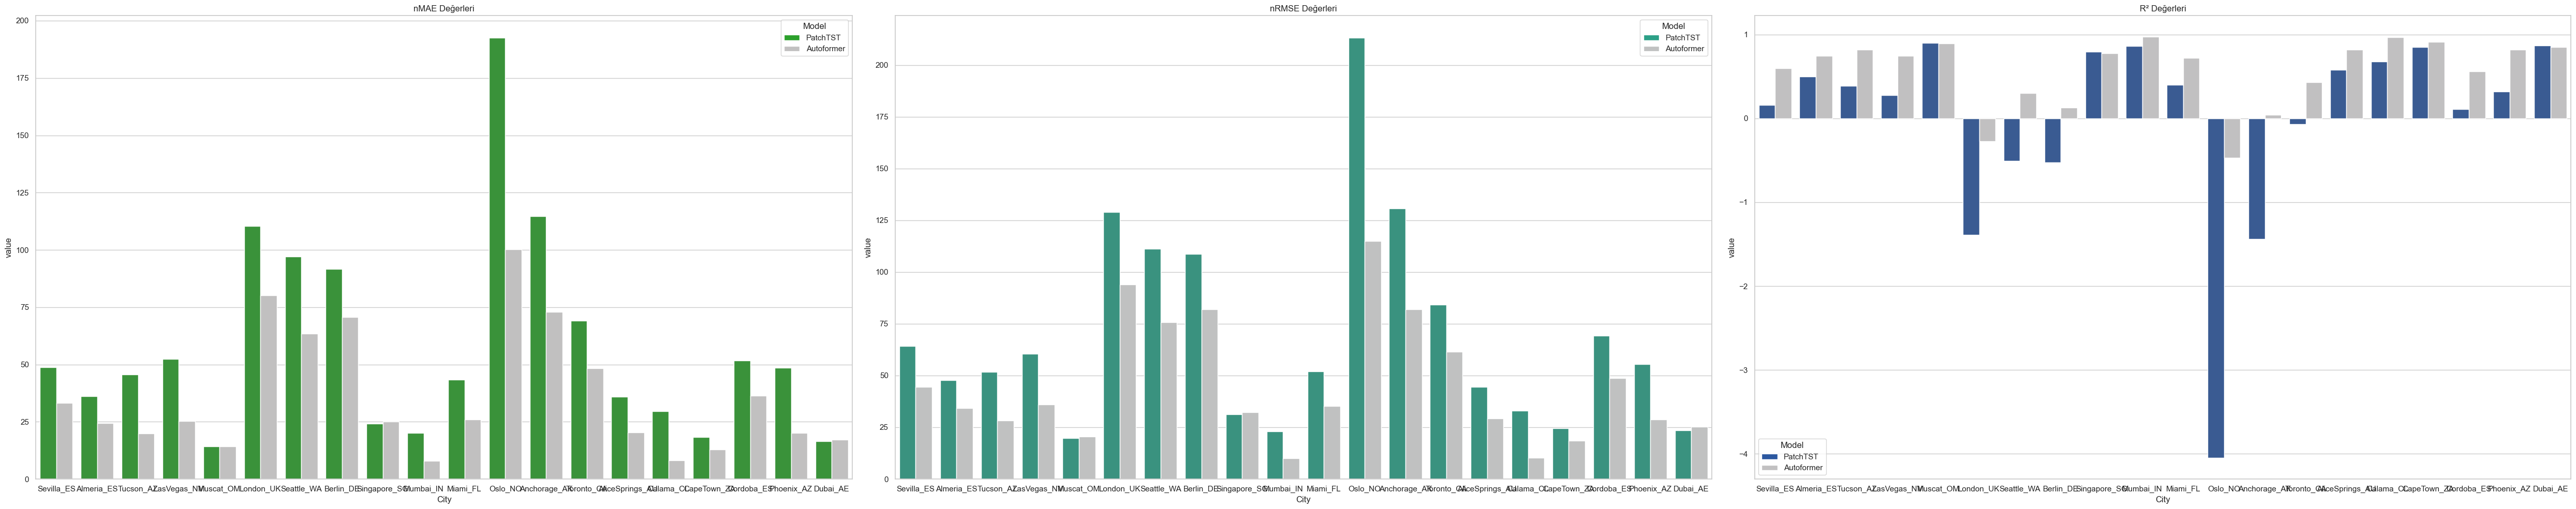

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch #MSE ve MAE yüzdelik olarak bahsetmen gerekir.

# Veriyi hazırlayalım (Eğer results_df zaten tanımlıysa bu bloğu atlayabilirsin)
# results_df burada kullanılıyor

# Plot ayarları
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(50, 10))

# Paletler (legend ile tam uyumlu renkler)
pal_nmae = {'P_nMAE': '#2ca02c', 'A_nMAE': "#c1c0c0"}
pal_nrmse = {'P_nRMSE': "#2ca087", 'A_nRMSE': "#c0c1c1"}
pal_r2 = {'P_R2': "#2c58a0", 'A_R2': "#c1c0c1"}

# 1. MAE Plot
sns.barplot(data=results_df.melt(id_vars='City', value_vars=['P_nMAE', 'A_nMAE']), 
            x='City', y='value', hue='variable', ax=axes[0], palette=pal_nmae)
axes[0].set_title('nMAE Değerleri')
handles_nmae = [Patch(facecolor=pal_nmae['P_nMAE']), Patch(facecolor=pal_nmae['A_nMAE'])]
axes[0].legend(handles_nmae, ['PatchTST', 'Autoformer'], title='Model')

# 2. RMSE Plot
sns.barplot(data=results_df.melt(id_vars='City', value_vars=['P_nRMSE', 'A_nRMSE']), 
            x='City', y='value', hue='variable', ax=axes[1], palette=pal_nrmse)
axes[1].set_title('nRMSE Değerleri')
handles_nrmse = [Patch(facecolor=pal_nrmse['P_nRMSE']), Patch(facecolor=pal_nrmse['A_nRMSE'])]
axes[1].legend(handles_nrmse, ['PatchTST', 'Autoformer'], title='Model')

# 3. R2 Plot
sns.barplot(data=results_df.melt(id_vars='City', value_vars=['P_R2', 'A_R2']), 
            x='City', y='value', hue='variable', ax=axes[2], palette=pal_r2)
axes[2].set_title("R² Değerleri")
handles_r2 = [Patch(facecolor=pal_r2['P_R2']), Patch(facecolor=pal_r2['A_R2'])]
axes[2].legend(handles_r2, ['PatchTST', 'Autoformer'], title='Model')

plt.tight_layout()
plt.savefig('../outputs/plots/final_ood_comparison.pdf', bbox_inches='tight')
plt.show()